In [ ]:
import numpy as np
import pandas as pd
import hvplot.xarray
import hvplot.pandas
import pandas as pd
import xarray as xr
import holoviews as hv
from holoviews import opts
import plotly.express as px
from IPython.display import Image
import matplotlib.pyplot as plt
import cmocean
chunks = 12

# caminho para os dados da grade utilizados neste notebook
# path = '/home/alexandre/Dropbox/grade_2020/grade_2020-07_2023/data/raw_wheater_data_2_interpolate/'
path = 'C:\\Users\\Acer\\Desktop\\dados_BR-DWGD\\'

<center></html>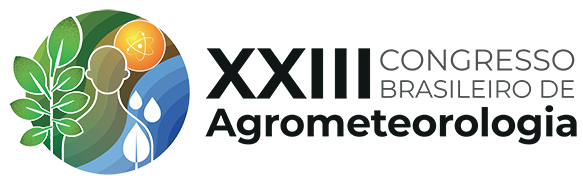
</body>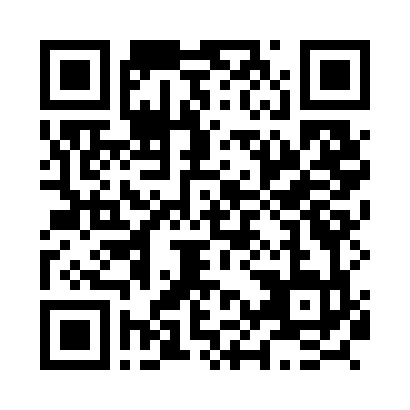

<center>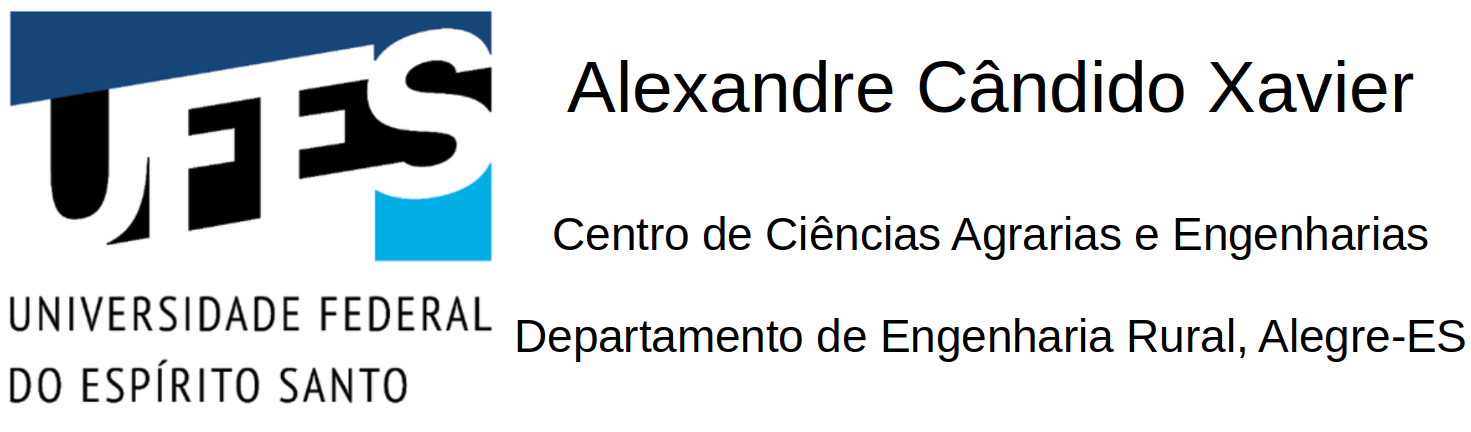

# Dados observados versus gradeados

Aspecto:

* **Precisão local**      
* **Cobertura espacial**  
* **Cobertura temporal**
* **Variáveis disponíveis**    
* **Confiabilidade em extremos**   
* **Dependência de modelos**     
* **Aplicações ideais**

# O que sempre achei difícil nos dados observados

In [ ]:
Image(filename='images/data_ana.png') 

In [ ]:
Image(filename='images/data_aguas_pr.png')

In [ ]:
Image(filename='images/data_inmet_auto.png') 

Decidiu usar dados observados, o que podemos encontrar?

In [ ]:
df = pd.read_csv('prec_erro_2246054.csv')
fig = px.line(df, x='time', y='pr', color='tipo', markers=True,
                  title=f'Estação: {2246054}', width=1350, height=600).update_traces(opacity=.4)
fig.update_layout(xaxis_title="Data", font=dict(size=20), legend=dict(x=0.8,y=0.9))
fig.update_traces(line=dict(width=3),hoverlabel=dict(font_size=20))
fig.show()

In [ ]:
df = pd.read_csv('Rs_erro_A357.csv')
fig = px.line(df, x='Unnamed: 0', y='A357', color='Dado', markers=True,
                  title=f'Estação: A357; Radiação solar', width=1350, height=600).update_traces(opacity=.4)
fig.update_layout(xaxis_title="Data", yaxis_title="Radiação solar", font=dict(size=20), legend=dict(x=0.01,y=0.9))
fig.update_traces(line=dict(width=3),hoverlabel=dict(font_size=20))
fig.show()


# *Brazilian Daily Weather Gridded Data* (BR-DWGD, Grade Brasileira de Dados Meteorológicos)

## Trabalhos

* **Xavier, A.C., King, C.W. and Scanlon, B.R. (2016), Daily gridded meteorological variables in Brazil (1980–2013). *International Journal of Climatology*, 36: 2644-2659. https://doi.org/10.1002/joc.4518**

* **Xavier, A. C., Scanlon, B. R., King, C. W., & Alves, A. I. (2022). New improved Brazilian daily weather gridded data (1961–2020). *International Journal of Climatology*, 42(16), 8390–8404. https://doi.org/10.1002/joc.7731**

* **Variáveis**:
  * Precipitação (pr, mm);
  * mínima e máxima temperatura (Tmax, Tmin, °C); 
  * radiação solar (Rs, MJ/m$^2$);
  * umidade relativa (RH, %);
  * velocidade do vento a 2 metros (u2, m/s)
  * evapotranspiração (ETo, mm).
    
* **Resolução temporal**:
  * Diária entre 01/jan/1961-20/mar/2024
      
* **Resolução espacial**:
  *  0,1° x 0,1° (~11 km x ~11 km);
  *  área de cada célula ~121 km$^2$;
  *  total de 70.330 células para cobrir o território

* **Download**:

  1. Google Drive da UFES: [aqui](https://drive.google.com/drive/u/1/folders/11-qnvwojirAtaQxSE03N0_SUrbcsz44N)
  2. One Drive da UFES: [aqui](https://ufesbr-my.sharepoint.com/personal/alexandre_xavier_ufes_br/_layouts/15/onedrive.aspx?id=%2Fpersonal%2Falexandre%5Fxavier%5Fufes%5Fbr%2FDocuments%2Fnetcdf%5Ffiles&ga=1)
  3. Google Earth Engine: [aqui](https://code.earthengine.google.com/?asset=projects/ee-alexandrexavier/assets/BR-DWGD)  

* **Informações da grade**: [aqui](https://sites.google.com/site/alexandrecandidoxavierufes/brazilian-daily-weather-gridded-data?authuser=0)

* **Versão atual**: **v_3.2.3** (01/Jan/1961-20/Mar/2024)


## Áreas da ciência que utilizaram a grade BR-DWGD

In [ ]:
# informações obtidas em: https://badge.dimensions.ai/details/id/pub.1148078922/categories (19/09/24)
df = pd.read_csv('area_citacao.csv', sep='\t', index_col='id_area')
fig = px.pie(df, values='Percentagem', names='Área', 
             title='<a style="text-align:center; font-size:40px;"; \
             href="https://badge.dimensions.ai/details/id/pub.1148078922/categories"> Área da pesquisa (Fonte Dimensions)</a>', 
             color_discrete_sequence=px.colors.sequential.RdBu, width=1300, height=650)
fig.update_layout(font=dict(size=24))
fig.update_traces(hoverlabel=dict(font_size=24))

## Material e métodos

### Dados observados (paper 2022)
Dados brutos de estações meteorológicas do Instituto Nacional de Meteorologia (INMET), e de pluviômetros, majoritariamente, aqueles disponibilizados pela Agência Nacional de Águas (ANA) através do Hidroweb.

* 11.473 pluviômetros (precipitação)
* 1.252 estações meteorológicas (Tmax, Tmin, Rs, RH e u2).

### Qualidade dos dados observados

* Eliminação dos dados discrepantes

<center>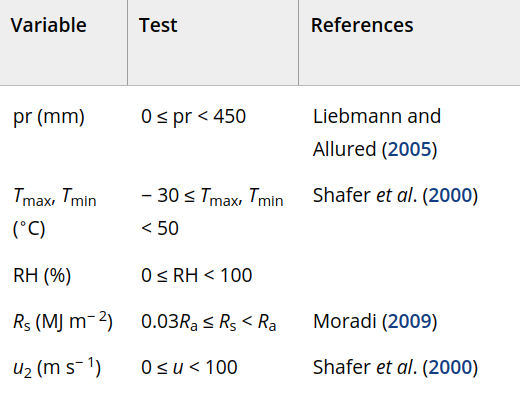

Tabela 2 [Xavier et al. (2022)](https://rmets.onlinelibrary.wiley.com/doi/full/10.1002/joc.4518)

* Teste visual de homogeneidade

### Interpolação

Na versão atual (Xavier et al. 2022) foram considerados dois métodos de interpolação:

* "Inverso do Quadrado da Distância" (*inverse distance weighting*, **IDW**) e;

* "Ponderação pela Distância Angular" (*angular distance weighting*, **ADW**)

Escolha do melhor método por meio de estatísticas (e.g.: R, bias; RMSE) dos dados diários da tabulação cruzada $(\mathrm{observado}\,(X)\,vs\, \mathrm{estimado}\,(Y))$.

## Versão atual

* versão: **v_3.2.3**

<center><a href="https://bi0s.unicamp.br/climaterna/"><img width="1000" height="1000" src="data:image/png;base64,
..."/></a>

**Número de pluviômetros/estações ao longo do tempo**

Arquivos "pr.npz" e "Tmax.npz" são os dados observados utilizados na interpolação.
Podem ser encontrados [aqui](https://drive.google.com/drive/u/0/folders/1urYczkKxBcXWHAmx04lle6jcbiTQS-bR)

In [ ]:
# lendo dados observados de precipitação e Tmax utilizado na construção da grade
prec_obs = np.load(path + 'pr.npz', allow_pickle=True)['data']
tmax_obs = np.load(path + 'Tmax.npz', allow_pickle=True)['data']
dates = pd.date_range('1961-01-01', '2024-03-20')

In [ ]:
def create_df(var, name):
    index = ~np.isnan(var)
    df = pd.DataFrame(index.sum(axis=1), columns=['Número'])
    df['Dia'], df['Tipo'] = dates, name
    return df

In [ ]:
df_pluvi = create_df(prec_obs, 'Pluviômetro')
fig = px.line(df_pluvi, x=['Dia'], y='Número', color='Tipo', 
        title='Variação do número de pluviômetros no tempo', height=600)
fig.update_layout(xaxis_title="Data", font=dict(size=20), 
                  legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01))
fig.update_traces(line=dict(width=3), hoverlabel=dict(font_size=24))

In [ ]:
df_estac = create_df(tmax_obs, 'Estação')
fig = px.line(df_estac, x=['Dia'], y='Número', color='Tipo', 
        title='Variação do número de estações no tempo', height=600)
fig.update_layout(xaxis_title="Data", font=dict(size=20), 
                  legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01))
fig.update_traces(line=dict(width=3), hoverlabel=dict(font_size=24))

# Grade e exemplos

A grade é armazenada e diponibilizada na estrutura de arquivos formato [NetCDF](https://www.unidata.ucar.edu/software/netcdf/).

## Vendo variável Tmax

In [ ]:
# Defina variável
name_var = 'Tmax' # ['Tmax', 'Tmin', 'pr', 'RH', 'Rs', 'ETo', 'u2']

# lendo variável
tmax = xr.open_mfdataset(f'{path}{name_var}*.nc', chunks={'time': chunks})[name_var]
tmax

In [ ]:
# tmax.encoding

Diferentes maneiras de vizualização

In [ ]:
tmax[0].plot()

In [ ]:
tmax.sel(time='1972-03-18').plot()

In [ ]:
tmax.sel(time='1972-03-18', longitude=-53, method='nearest').plot()

Pegando dados para uma posição

In [ ]:
tmax_pos = tmax.sel(latitude=-30, longitude=-51, method='nearest').compute()
tmax_pos.plot()

Reamostrando para escala de tempo anual

In [ ]:
tmax.sel(latitude=-30, longitude=-51, method="nearest").resample(time="YE").mean().plot()

Se quiser iterativo, basta trocar o "plot()" por "hvplot()"

In [ ]:
tmax.sel(time='1972-03-18').hvplot(geo=True)

In [ ]:
tmax.sel(time='1972-03-18').hvplot(geo=True, cmap='jet', tiles=True, label='tmax', frame_width=500)

In [ ]:
tmax.sel(latitude=-30, longitude=-51, method='nearest').hvplot()

In [ ]:
tmax.sel(latitude=-30, longitude=-51, method="nearest").resample(time="YE").mean().hvplot(responsive=True, height=400)

## Aplicação prática I - Índice de Aridez

Inspiração:

Tomasella, J.; Cunha, A.M.A.; Zeri, M.; Costa L.C.O.
Changes in the aridity index across Brazilian biomes. *Science of The Total Environment*,
V 989, 2025. [https://doi.org/10.1016/j.scitotenv.2025.179869](https://doi.org/10.1016/j.scitotenv.2025.179869)

$\displaystyle AI = \frac{pr}{ETo}$

sendo $AI$ é o índice de aridez e; $pr$ e $ETo$, respectivamente, a média da precipitação e evapotranspiração anual no período.  

No paper é comparado diferentes períodos, vamos utilizar o período de 1961-01-01 à 1990-12-31

In [ ]:
# definindo os períodos e lendo as variáveis 
# precipitação (pr) e ETo (eto)
time_start, time_end = '1961-01-01', '1990-12-31'

pr = xr.open_mfdataset(f'{path}pr*.nc', chunks={'time': chunks})['pr']\
       .loc[dict(time=slice(time_start, time_end))]

eto = xr.open_mfdataset(f'{path}ETo*.nc', chunks={'time': chunks})['ETo']\
        .loc[dict(time=slice(time_start, time_end))]

In [ ]:
eto[-1].plot()

In [ ]:
# criando mascara para o continente e mar
mask_ocean = 2 * np.ones(pr.shape[1:]) * np.isnan(pr.isel(time=0))
mask_land = 1 * np.ones(pr.shape[1:]) * ~np.isnan(pr.isel(time=0))
mask_array = (mask_ocean + mask_land).values
pr.coords['mask'] = xr.DataArray(mask_array, dims=('latitude', 'longitude'))

**Calculando a média anual para o período**

In [ ]:
pr_mean_year = pr.resample(time='YE').sum().mean(dim='time').where(pr.mask == 1).compute()
eto_mean_year = eto.resample(time='YE').sum().mean(dim='time').where(pr.mask == 1).compute()
AI = pr_mean_year/eto_mean_year

Plotando

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

pr_mean_year.plot(ax=axes[0], cmap=cmocean.cm.balance_r, vmin=400, vmax=2100)
eto_mean_year.plot(ax=axes[1], cmap='jet', vmin=1200, vmax=2000)
AI.plot(ax=axes[2], cmap='Spectral', vmin=0.2, vmax=2)

for n, var in enumerate(['PR (mm/ano)', 'ETo (mm/ano)', 'IA']):
    axes[n].set_aspect('equal')
    axes[n].set_axis_off()
    axes[n].set_title(var)

fig.suptitle(f'{time_start} à {time_end}', fontsize=16, fontweight='bold')

In [ ]:
# prec = xr.open_mfdataset(f'{path}pr*.nc', chunks={'time': 10000})['pr']
# prec

In [ ]:
# prec.mean(dim='time').data.visualize(optimize_graph=True)

## Aplicação prática I - Visualizando eventos climáticos

Baseado no trabalho:

Collischonn, Walter; Fialho Brêda, J.P.L; Wongchuig, S.; Ruhoff, A.;
de Paiva, R.C.D.; Fan, F.M.; Machado Filho, R.C.C. &
Ramalho, N. Chuvas sem precedentes de abril a maio de 2024 no Sul do Brasil definem novo recorde. (2024). *Revista Brasileira de Recursos Hídricos*. [https://doi.org/10.1590/2318-0331.292420240088](https://doi.org/10.1590/2318-0331.292420240088)

In [ ]:
var_name = 'pr'
pr = xr.open_mfdataset(f'{path}{var_name}*.nc', chunks={'time': chunks})['pr']

In [ ]:
# escolhedo um dos maiores evendo de chuva de curta
# tempo: SC/PR: '2014-06-05','2014-06-10'; 
# SC/PR/RS '1983-07-05','1983-07-12'; 
# SC/PR/RS '1992-05-26', '1992-05-30' 
pr_periodo = pr.sel(time=slice('1983-07-05','1983-07-12'),
                    latitude=slice(-33,-24), 
                    longitude=slice(-60,-45))
pr_periodo

Precipitação acumulada no período

In [ ]:
pr_acumu = pr_periodo.sum('time')
pr_acumu.where(pr_acumu > 100) \
        .hvplot(cmap=cmocean.cm.balance_r, geo=True,
                tiles=True, label='pr', frame_width=600)

Precipitação diária para o período

In [ ]:
pr_periodo2plot = hv.Dataset(pr_periodo)
pr_periodo2plot = pr_periodo2plot.to(hv.Image, kdims=["longitude", "latitude"], dynamic=False)
pr_periodo2plot.opts(cmap="jet", colorbar=True, width=900, height=600, fontscale=2)

## No Google Earth Engine

BR-DWGD no Google Earth Engine: [aqui](https://code.earthengine.google.com/?asset=projects/ee-alexandrexavier/assets/BR-DWGD)  

Exemplo em *JavaScript*: [aqui](https://code.earthengine.google.com/04e2cd1fdb0f8347c0241c57408668e1) e [aqui](https://code.earthengine.google.com/8d0c382b16246db07827979409c93a4b)

Para chamar a base BR-DWGD: ```ee.ImageCollection('projects/ee-alexandrexavier/assets/BR-DWGD')```

In [ ]:
import geemap
import ee
import geemap.colormaps as cm
palette = cm.palettes.jet

In [ ]:
ee.Authenticate()

In [ ]:
ee.Initialize(project="ee-alexandrexavier") # ee-alexandrexavier # ee-my-xavierac tem que colocar o nome do seu projeto

Primeira imagem

In [ ]:
ee.ImageCollection('projects/ee-alexandrexavier/assets/BR-DWGD').first()

In [ ]:
# variável (bands)
var_name = 'Tmax' # ('Rs', 'u2', 'Tmax', 'Tmin', 'RH', 'pr', 'ETo')

# reescalonando para a unidade de graus Celsius
offset = 15
scale  = 0.00106815

# definindo período (tem limite)
start_date, end_date = '2022-02-01','2024-03-22'

# coordenada do ponto de interesse [lon, lat]
lon_lat = [-51, -30]
point = {'type': 'Point', 'coordinates': lon_lat}

In [ ]:
var = ee.ImageCollection('projects/ee-alexandrexavier/assets/BR-DWGD') \
                        .filterDate(start_date, end_date) \
                        .select(var_name)
var.first()

In [ ]:
# reescalonando
def scaleBand(image):
    scaledImage = image.select(var_name) \
                       .multiply(scale) \
                       .add(offset) 
    return scaledImage.copyProperties(image, image.propertyNames())

var = var.map(scaleBand)

In [ ]:
var.first()

In [ ]:
# informações para plotar o mapa da precipitação
vis = {'min': 20,'max': 40, 'palette': cm.palettes.jet}

In [ ]:
m = geemap.Map()
m.addLayer(var.first(), vis, 'Precipitação')
m.addLayer(ee.Feature(point), {'color': 'red'}, "posição")
m

Pegando informações para uma posição. Pode demorar um pouco se o intervalo de tempo for grande.

In [ ]:
dados = var.getRegion(point, scale=10000).getInfo()

Criando dataframe

In [ ]:
df = pd.DataFrame(dados[1:], columns=dados[0])
df.index = pd.to_datetime(df['id'].str.split('_').str[-1])
df.index.set_names('Data', inplace=True)
df

In [ ]:
# plotando
fig = px.line(df, x=df.index, y=var_name,
              title=f"{var_name} na lat={lon_lat[1]}; lon={lon_lat[0]}", height=600)
fig.update_traces(hovertemplate="Data: %{x} <br>" + var_name + ": %{y:.1f}")
fig.show()

# Sobre atualizações

* A disponililização dos dados observados na ANA e INMET não é diária (principalmente os da ANA, precipitação)

* Necessidade de verificação dos dados observados de todas as estações/variáveis

* Difícil construção de verificação automática

<p style="text-align:center; font-size:80px;">Obrigado!</p>

<center><img width="1000" height="1000" src="data:image/png;base64,